In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [86]:
df_data = pd.read_parquet("training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached

unique_ids = df_train_detached["Property_ID"].unique()
df_house = pd.read_csv('training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual", "HP_Size_kW"
]

# calculate min capacity in home 
cp_air = 1.005  #kJ/kgK
rho_air = 1.225  # kg/m^3
kj_to_kWh = 1 / 3600
df_house["Volume"] = df_house["Total_Floor_Area"] * df_house["Floor_Height"]
df_house["Min Capacity"] = df_house["Volume"] * cp_air * rho_air * kj_to_kWh

df_home_values = df_house[df_house["Property_ID"].isin(unique_ids)]

summary = df_home_values[["Property_ID", "Min Capacity"]].drop_duplicates()
#print(summary)


In [87]:
# results to test
results = pd.read_csv('trained_params_v2.csv')

for id_use in unique_ids:
    print(results[id_use][5])

3.0000000000000013
2.500000000000001
5.900000000000004
5.900000000000004
1.5
5.900000000000004
4.8000000000000025
2.3000000000000007
5.100000000000003
3.5000000000000018


In [88]:
for id_use in unique_ids:
    
    floor_area = float(results[id_use][0][6:])
    no_storeys = float(results[id_use][1][6:])
    insulation = results[id_use][2][6:]
    hp_type = results[id_use][3][6:]
    rating = results[id_use][4][6:]
    C = float(results[id_use][5])
    R_a = float(results[id_use][6])
    w_s = float(results[id_use][7])
    w = float(results[id_use][9])
    
    home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")
    df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
        "Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single[
        "Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] -
         df_single["Internal_Air_Temperature"])
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.90 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
        method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy()
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    df_heating_single = df_single_processed.copy()
    
    # Time range
    t_start = pd.to_datetime("2023-01-01 00:00:00")
    t_end = pd.to_datetime("2023-01-31 23:59:00")
    df_heating_only = df_heating_single[
        (df_heating_single.index >= t_start) & (df_heating_single.index <= t_end)
        ].copy()
    
    df_heating_only.drop("Property_ID", axis=1, inplace=True)
    df_heating_only.drop("half-hour", axis=1, inplace=True)
    df_heating_only.drop("Date", axis=1, inplace=True)
    df_heating_only.drop("has_data", axis=1, inplace=True)
    
    t_step_regres = 12

    # Select numeric columns and resample
    df_numeric = df_heating_only.select_dtypes(include='number')
    df_resampled = df_numeric.resample(f'{t_step_regres}h').mean()
    
    # Extract variables
    delta_T_a_heat = df_resampled["Internal_Ambient_Temperature_Diff"].dropna()
    q_heat_only = df_resampled["Heat_Pump_Energy_Output_Diff"].dropna()
    
    # Align lengths
    valid_idx = delta_T_a_heat.index.intersection(q_heat_only.index)
    delta_T_a_heat = delta_T_a_heat.loc[valid_idx]
    q_heat_only = q_heat_only.loc[valid_idx]
    
    # Regression (Y = a*X + b)
    Y = q_heat_only.values
    X = np.vstack([delta_T_a_heat.values, np.ones(len(delta_T_a_heat))]).T
    coef, resid, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    rmse = resid / np.sqrt(len(delta_T_a_heat.values))
    
    # Generate fit line
    x_step = np.linspace(delta_T_a_heat.min(), delta_T_a_heat.max(), 100)
    y_step = coef[0] * x_step + coef[1]
    
    print(f"RMSE:{rmse}")
    
    # Generate fit line
    x_step = np.linspace(delta_T_a_heat.min(), delta_T_a_heat.max(), 100)
    y_step = coef[0] * x_step + coef[1]
    
    # Compute predicted values
    predicted = coef[0] * delta_T_a_heat.values + coef[1]
    
    # Compute residuals
    residuals = q_heat_only.values - predicted
    
    # Compute RMSE
    rmse = np.sqrt(np.mean(residuals ** 2))
    
    # Mask: points that are more than 1 RMSE ABOVE the fit
    above_mask = residuals > rmse
    below_mask = residuals <= rmse
    # Convert to DataFrame for easier handling
    df_check = pd.DataFrame({
        "q_actual": q_heat_only.values,
        "q_predicted": predicted,
        "above_line": above_mask
    }, index=delta_T_a_heat.index)
    
    # Extract timestamps where actual > predicted
    above_points = df_check[df_check["above_line"]].index
    
    
    #  Add date column
    df_check["date"] = df_check.index.date
    
    # Identify dates where at least one point is above the regression line
    dates_with_above = df_check.loc[df_check["above_line"], "date"].unique()
    
    #  Create daily masks
    df_check["above_day"] = df_check["date"].isin(dates_with_above)
    df_check["below_day"] = ~df_check["above_day"]
        
    df_heating_only = df_heating_single[
    (df_heating_single.index >= t_start) & (df_heating_single.index <= t_end)
    ].copy()
    
    # --- Apply clean-day mask to original 30-min data ---
    below_dates = df_check.loc[df_check["below_day"], "date"].unique()
    
    df_heating_only["date"] = df_heating_only.index.date
    df_below_days_only = df_heating_only[df_heating_only["date"].isin(below_dates)].copy()
    df_below_days_only.drop(columns=["date"], inplace=True)
    
    
    t_step = 30  # minutes
    delta_t = t_step / 60
    
    T_a_val = (df_below_days_only["External_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    T_i_val = (df_below_days_only["Internal_Air_Temperature"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
    delta_T_a_val = (df_below_days_only["Internal_Ambient_Temperature_Diff"].iloc[:-1]
                 .reset_index(drop=True).to_numpy()) 
    delta_T_i_val = (df_below_days_only["Internal_Temperature_Diff"].iloc[1:]
                 .reset_index(drop=True).to_numpy() / delta_t) 
    q_hp_val = (df_below_days_only["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
            .reset_index(drop=True).to_numpy()) 
    q_solar_val = (df_below_days_only["SolarRadiation"].iloc[:-1].reset_index
               (drop=True).to_numpy()) 
    v_wind_val = (df_below_days_only["Windspeed"].iloc[:-1].reset_index(drop=True)
              .to_numpy()) 
    
    q_hat_sim = (delta_T_i_val * C -  delta_T_a_val / R_a * delta_t  - w_s *  
    q_solar_val  - w * np.ones(len(T_a_val), )* delta_t )
    
    rmse_q = np.sqrt((q_hat_sim - q_hp_val) ** 2).mean()
    
    print(f"RMSE between simulated and actual heat: {rmse_q:.3f} kWh")
    
    simulated_T_i = []
    
    # Reset index for safety
    df = df_below_days_only.copy()
    df = df.sort_index()
    df["date"] = df.index.date
    
    # Group by day
    for date, df_day in df.groupby("date"):
        df_day = df_day.copy()
    
        # Drop last row to match delta_T_i indexing if needed
        q_hp_val     = df_day["Heat_Pump_Energy_Output_Diff"].iloc[:-1].to_numpy()
        delta_T_a_val= df_day["Internal_Ambient_Temperature_Diff"].iloc[:-1].to_numpy()
        q_solar_val  = df_day["SolarRadiation"].iloc[:-1].to_numpy()
        wind_val     = df_day["Windspeed"].iloc[:-1].to_numpy()  # unused?
        T_i_start    = df_day["Internal_Air_Temperature"].iloc[0]
    
        # Number of steps
        N = len(q_hp_val)
    
        # Initialize T_i array
        T_i_sim_day = np.zeros(N + 1)
        T_i_sim_day[0] = T_i_start
    
        # Step forward using the thermal model
        for k in range(N):
            delta_T_i_k = (q_hp_val[k] + delta_T_a_val[k] / R_a * delta_t + 
                           w_s * q_solar_val[k] + w * delta_t) / C
            T_i_sim_day[k+1] = T_i_sim_day[k] + delta_T_i_k * delta_t
    
        # Append simulated temps (excluding first to avoid duplicate midnights)
        simulated_T_i.append(pd.Series(T_i_sim_day[1:], index=df_day.index[1:]))
    
    # Concatenate into single time series
    simulated_T_i_full = pd.concat(simulated_T_i).sort_index()
    
    # Get actual T_i values for comparison (drop first step of each day)
    T_i_actual = df_below_days_only["Internal_Air_Temperature"].copy()
    
    # Align and drop any mismatch
    sim_actual_common = pd.concat([simulated_T_i_full, T_i_actual], axis=1, join="inner")
    sim_actual_common.columns = ["T_i_sim", "T_i_actual"]
    
    # Compute RMSE
    rmse_T = np.sqrt(np.mean((sim_actual_common["T_i_sim"] - 
                              sim_actual_common["T_i_actual"]) ** 2))
    print(f"RMSE between simulated and actual internal temperature: {rmse_T:.3f} °C")

    
    
    

RMSE:[0.30347671]
RMSE between simulated and actual heat: 0.501 kWh
RMSE between simulated and actual internal temperature: 1.811 °C
RMSE:[0.32322799]
RMSE between simulated and actual heat: 0.712 kWh
RMSE between simulated and actual internal temperature: 1.962 °C
RMSE:[0.22532037]
RMSE between simulated and actual heat: 1.324 kWh
RMSE between simulated and actual internal temperature: 1.330 °C
RMSE:[0.34351692]
RMSE between simulated and actual heat: 1.168 kWh
RMSE between simulated and actual internal temperature: 0.525 °C
RMSE:[0.47604205]
RMSE between simulated and actual heat: 0.511 kWh
RMSE between simulated and actual internal temperature: 3.659 °C
RMSE:[1.00781118]
RMSE between simulated and actual heat: 0.959 kWh
RMSE between simulated and actual internal temperature: 1.112 °C
RMSE:[0.59176486]
RMSE between simulated and actual heat: 0.721 kWh
RMSE between simulated and actual internal temperature: 1.644 °C
RMSE:[1.55741496]
RMSE between simulated and actual heat: 0.771 kWh
R

RMSE:[0.30347671]


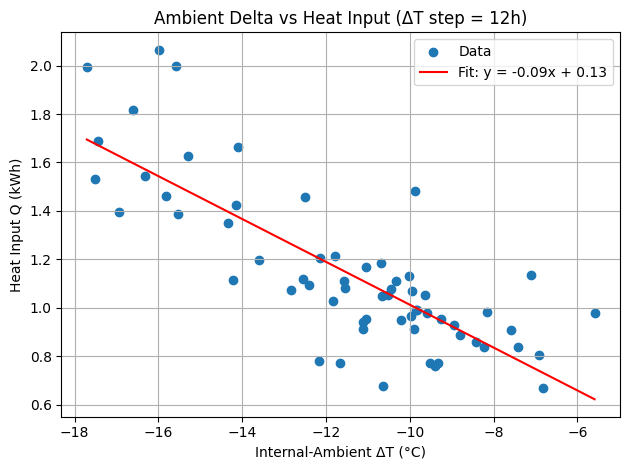

All time windows above the regression line:
[(Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-04 00:00:00')), (Timestamp('2023-01-17 00:00:00'), Timestamp('2023-01-17 00:00:00')), (Timestamp('2023-01-18 00:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-19 00:00:00'), Timestamp('2023-01-19 00:00:00')), (Timestamp('2023-01-20 00:00:00'), Timestamp('2023-01-20 00:00:00')), (Timestamp('2023-01-21 00:00:00'), Timestamp('2023-01-21 00:00:00')), (Timestamp('2023-01-22 00:00:00'), Timestamp('2023-01-22 00:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


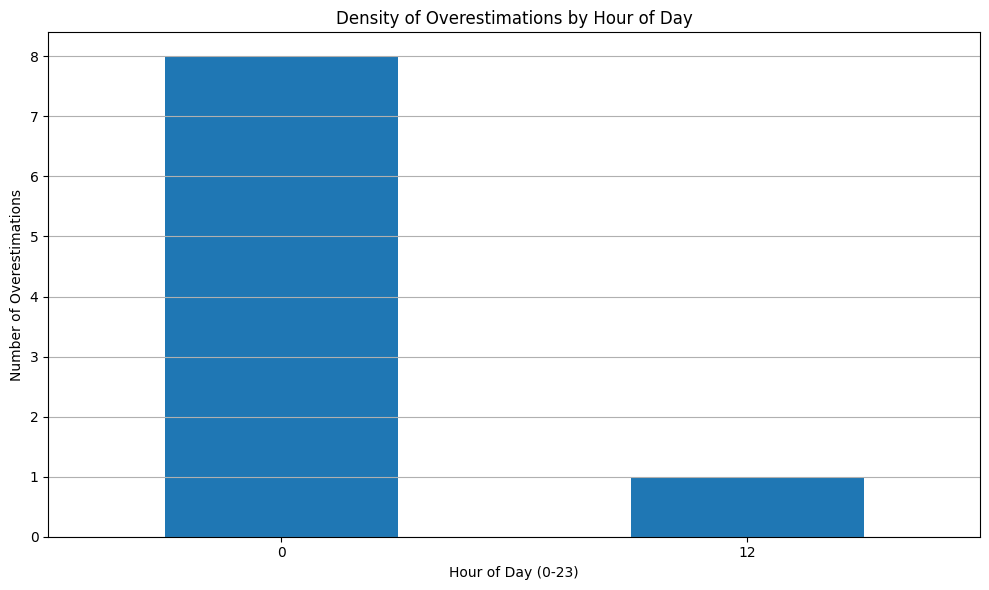

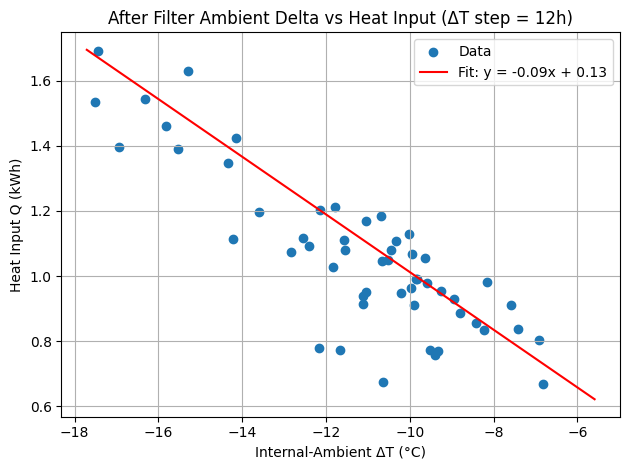

RMSE:[0.32322799]


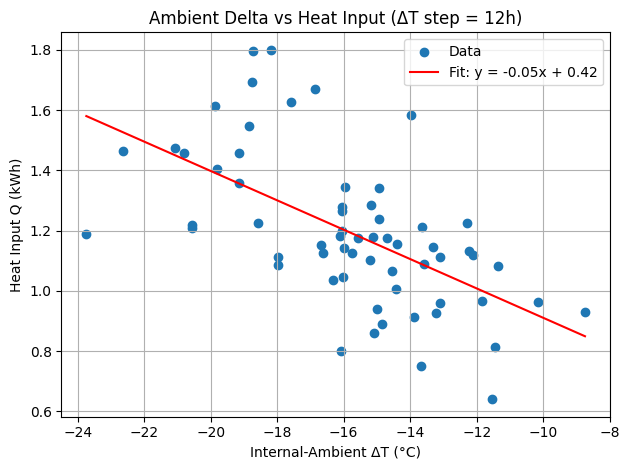

All time windows above the regression line:
[(Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-03 00:00:00')), (Timestamp('2023-01-18 00:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-19 12:00:00'), Timestamp('2023-01-20 00:00:00')), (Timestamp('2023-01-21 00:00:00'), Timestamp('2023-01-21 00:00:00')), (Timestamp('2023-01-22 00:00:00'), Timestamp('2023-01-23 00:00:00')), (Timestamp('2023-01-24 00:00:00'), Timestamp('2023-01-24 00:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


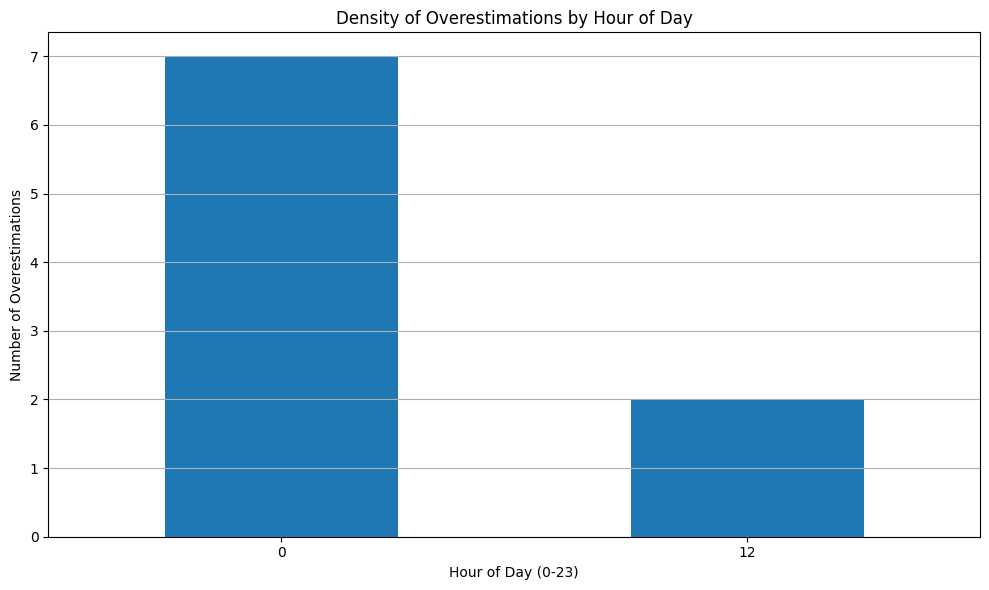

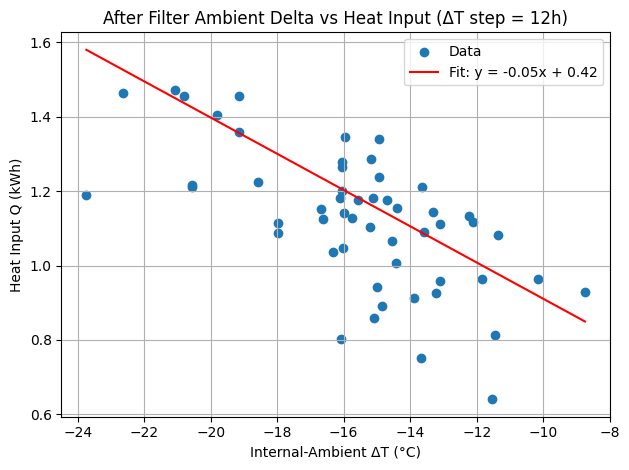

RMSE:[0.22532037]


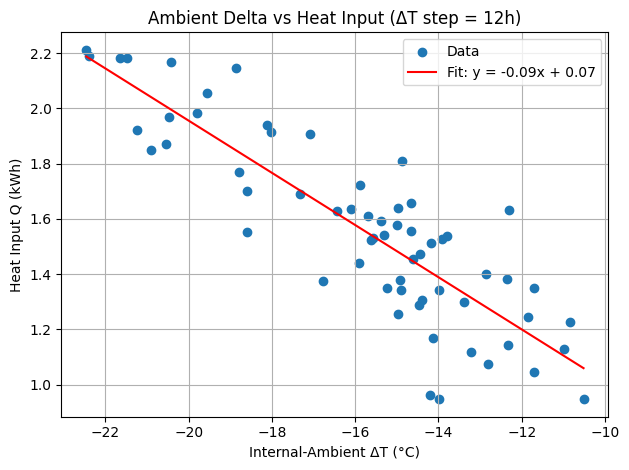

All time windows above the regression line:
[(Timestamp('2023-01-02 00:00:00'), Timestamp('2023-01-02 00:00:00')), (Timestamp('2023-01-03 12:00:00'), Timestamp('2023-01-03 12:00:00')), (Timestamp('2023-01-11 00:00:00'), Timestamp('2023-01-11 00:00:00')), (Timestamp('2023-01-14 12:00:00'), Timestamp('2023-01-14 12:00:00')), (Timestamp('2023-01-18 00:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-23 00:00:00'), Timestamp('2023-01-23 00:00:00')), (Timestamp('2023-01-30 00:00:00'), Timestamp('2023-01-30 00:00:00')), (Timestamp('2023-01-31 00:00:00'), Timestamp('2023-01-31 00:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


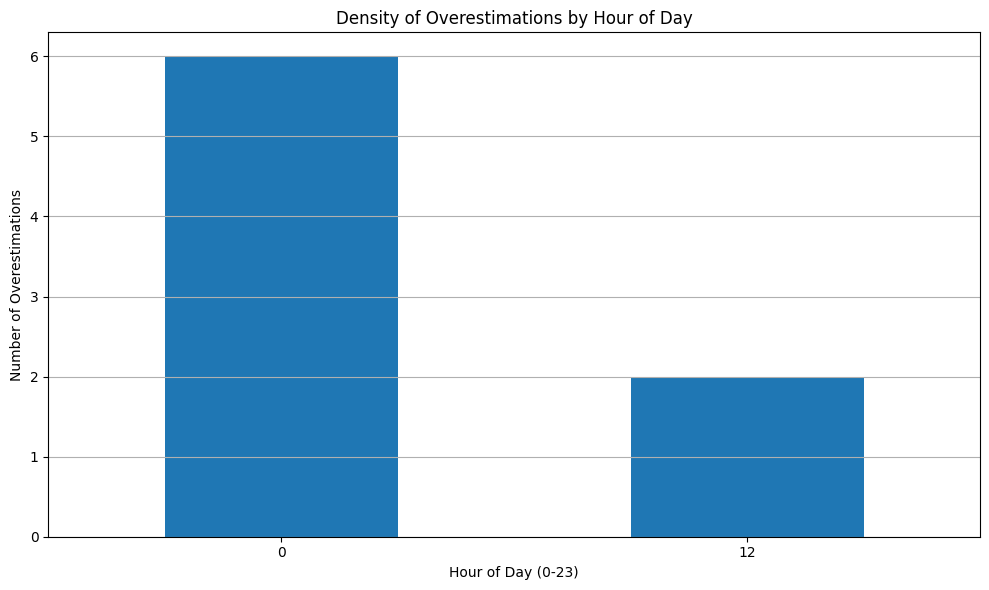

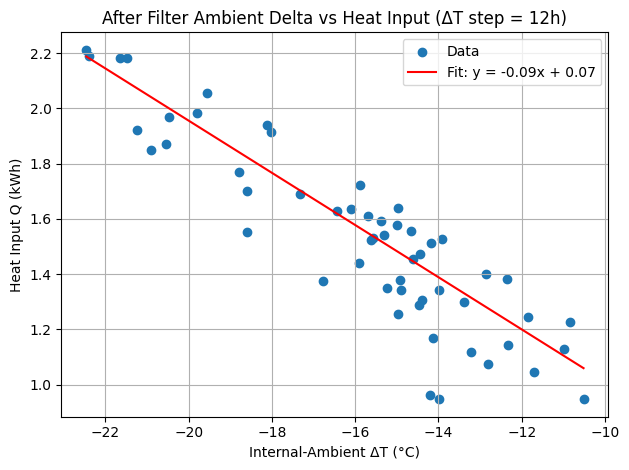

RMSE:[0.34351692]


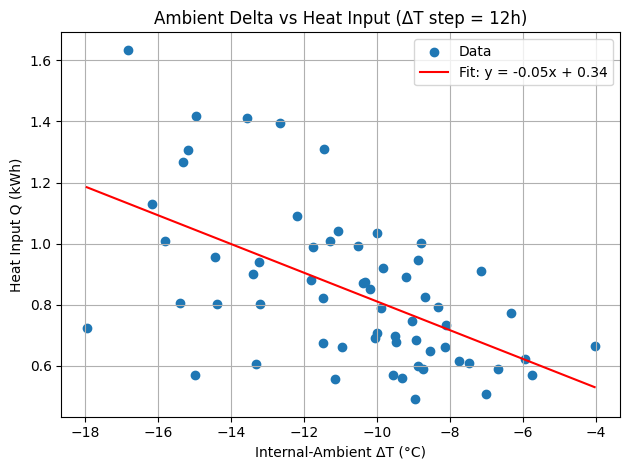

All time windows above the regression line:
[(Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-03 12:00:00')), (Timestamp('2023-01-10 00:00:00'), Timestamp('2023-01-10 00:00:00')), (Timestamp('2023-01-13 00:00:00'), Timestamp('2023-01-13 00:00:00')), (Timestamp('2023-01-16 00:00:00'), Timestamp('2023-01-16 00:00:00')), (Timestamp('2023-01-17 00:00:00'), Timestamp('2023-01-17 00:00:00')), (Timestamp('2023-01-18 00:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-19 00:00:00'), Timestamp('2023-01-19 00:00:00')), (Timestamp('2023-01-20 00:00:00'), Timestamp('2023-01-20 00:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


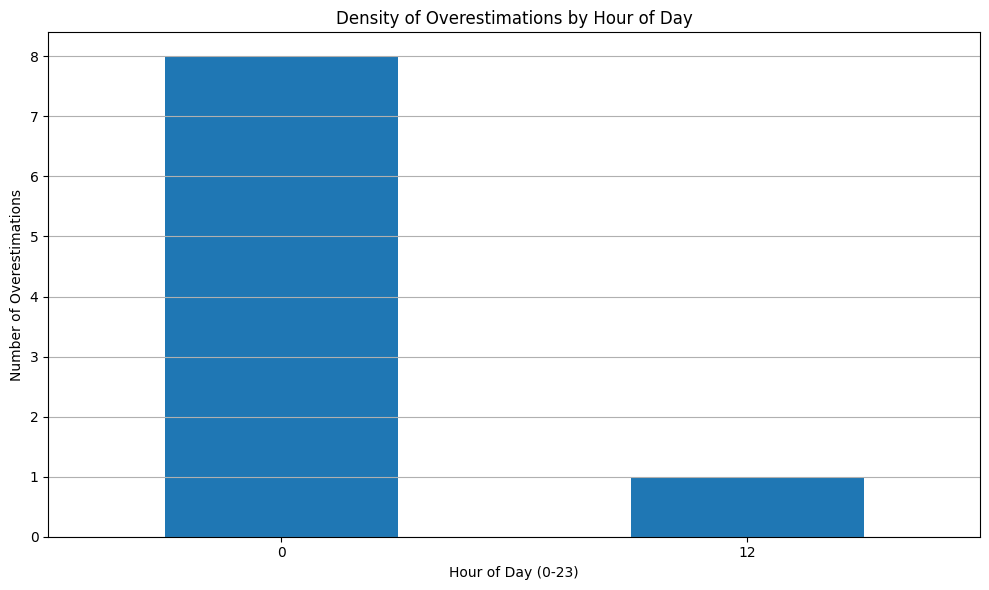

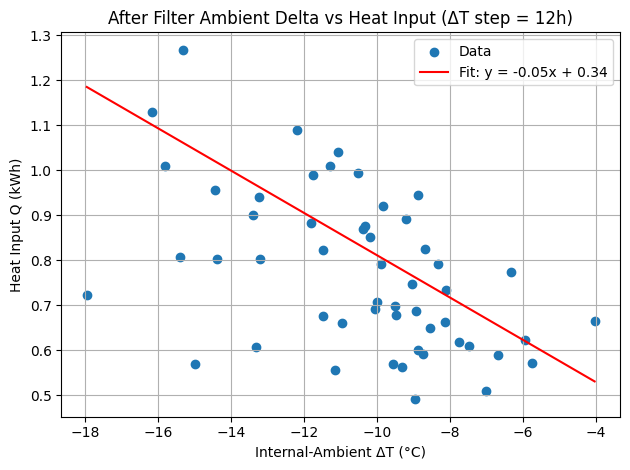

RMSE:[0.47604205]


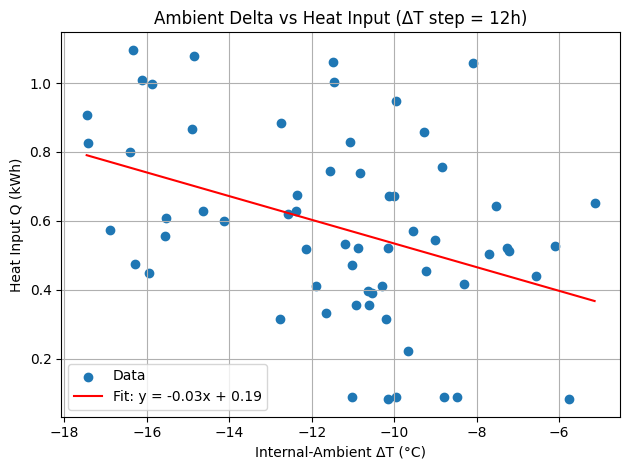

All time windows above the regression line:
[(Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-03 00:00:00')), (Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 12:00:00')), (Timestamp('2023-01-07 00:00:00'), Timestamp('2023-01-07 00:00:00')), (Timestamp('2023-01-09 12:00:00'), Timestamp('2023-01-10 00:00:00')), (Timestamp('2023-01-15 12:00:00'), Timestamp('2023-01-16 00:00:00')), (Timestamp('2023-01-17 12:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-19 00:00:00'), Timestamp('2023-01-19 00:00:00')), (Timestamp('2023-01-22 12:00:00'), Timestamp('2023-01-22 12:00:00')), (Timestamp('2023-01-29 12:00:00'), Timestamp('2023-01-29 12:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


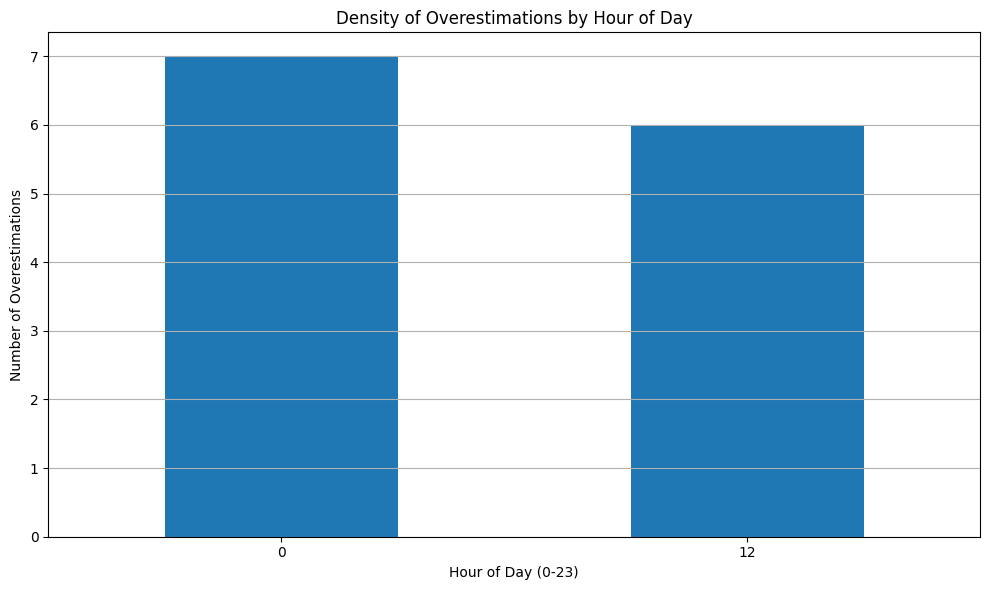

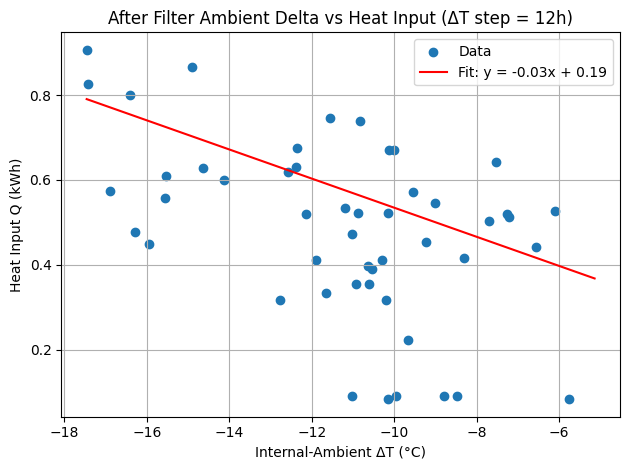

RMSE:[1.00781118]


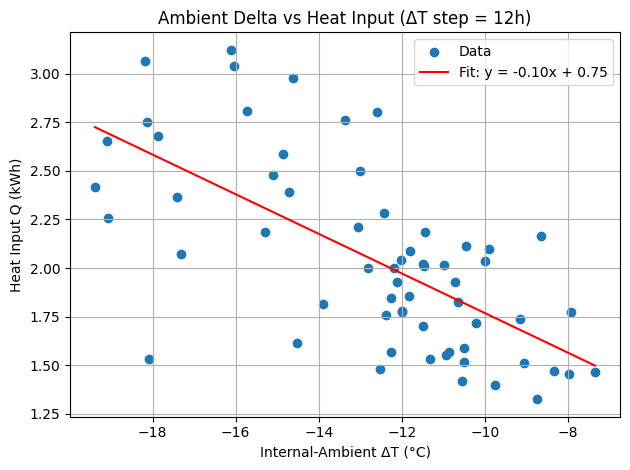

/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


All time windows above the regression line:
[(Timestamp('2023-01-10 12:00:00'), Timestamp('2023-01-10 12:00:00')), (Timestamp('2023-01-14 12:00:00'), Timestamp('2023-01-14 12:00:00')), (Timestamp('2023-01-17 12:00:00'), Timestamp('2023-01-19 12:00:00')), (Timestamp('2023-01-21 12:00:00'), Timestamp('2023-01-21 12:00:00')), (Timestamp('2023-01-31 12:00:00'), Timestamp('2023-01-31 12:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


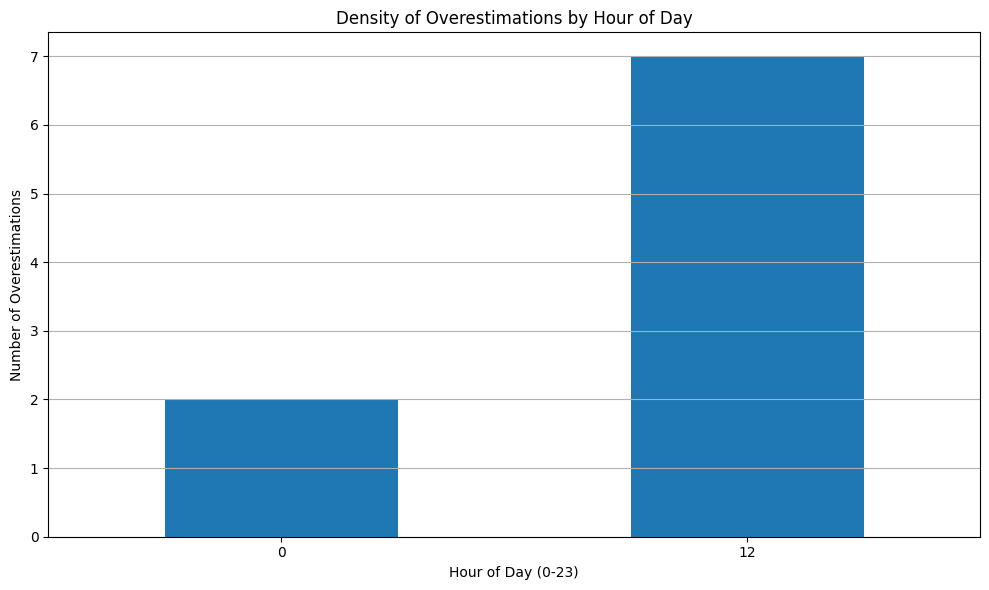

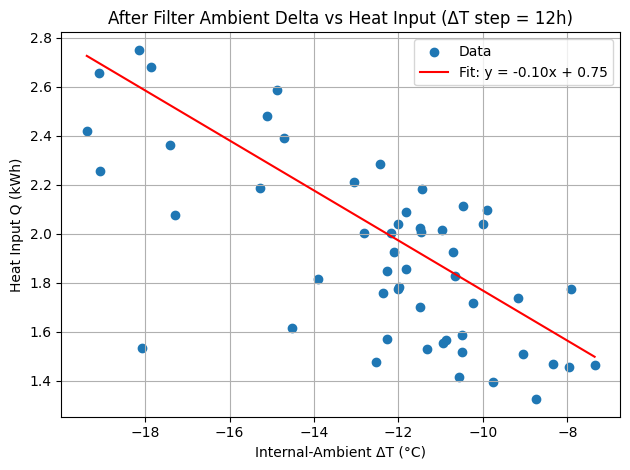

RMSE:[0.59176486]


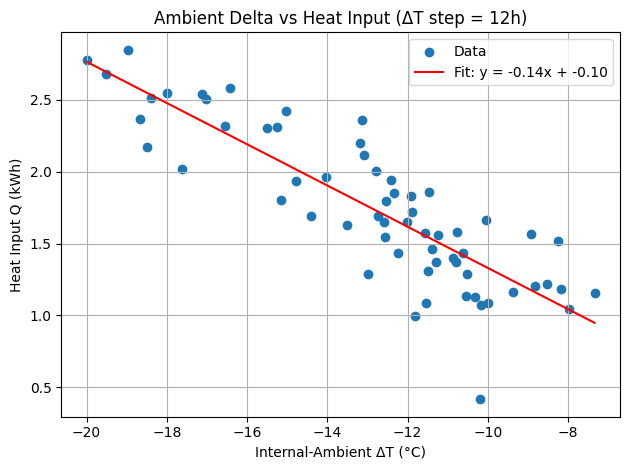

/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


All time windows above the regression line:
[(Timestamp('2023-01-03 00:00:00'), Timestamp('2023-01-03 12:00:00')), (Timestamp('2023-01-07 00:00:00'), Timestamp('2023-01-07 00:00:00')), (Timestamp('2023-01-12 00:00:00'), Timestamp('2023-01-12 00:00:00')), (Timestamp('2023-01-14 12:00:00'), Timestamp('2023-01-15 00:00:00')), (Timestamp('2023-01-18 00:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-21 12:00:00'), Timestamp('2023-01-21 12:00:00')), (Timestamp('2023-01-23 00:00:00'), Timestamp('2023-01-23 00:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


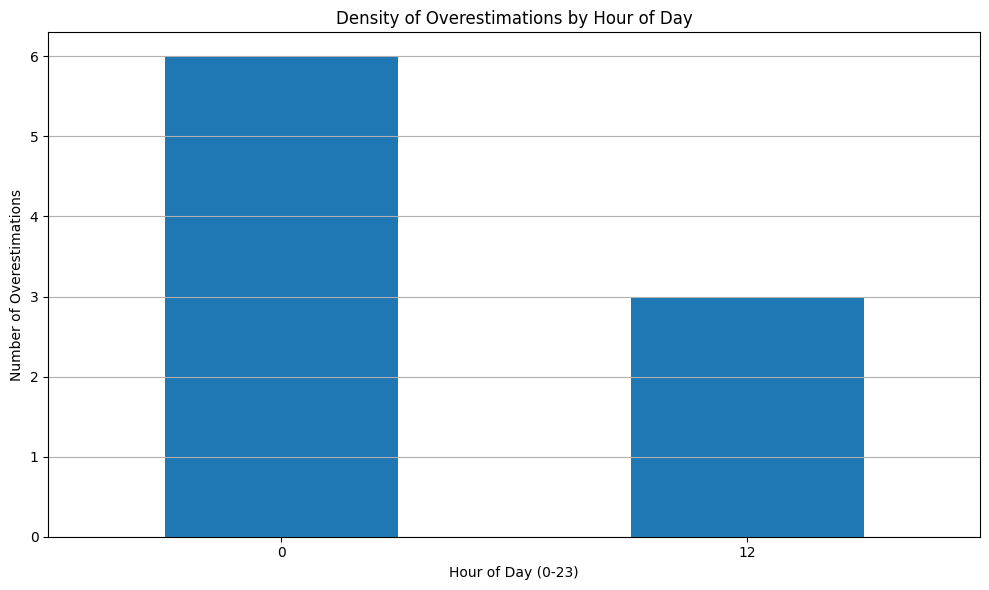

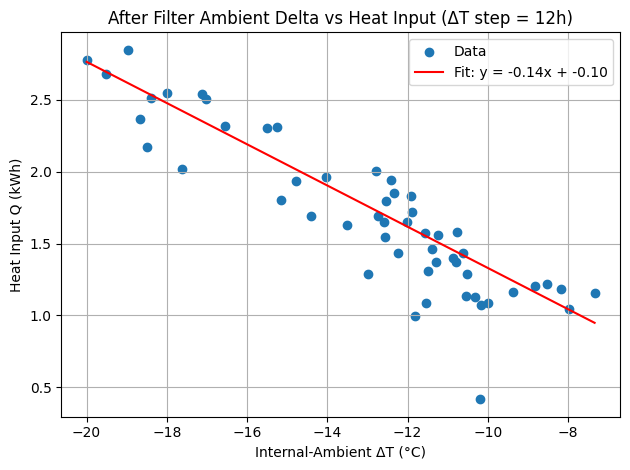

RMSE:[1.55741496]


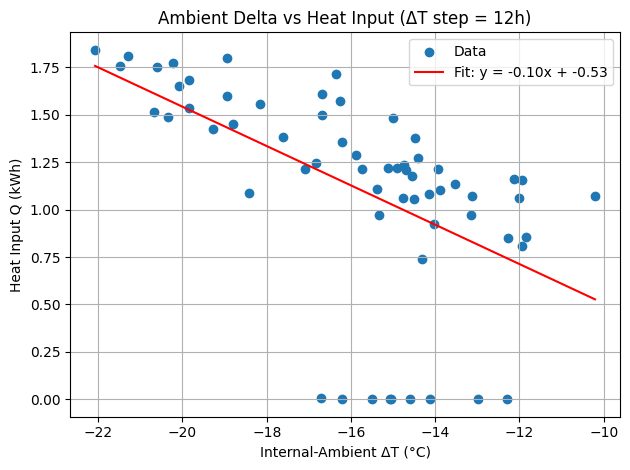

/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


All time windows above the regression line:
[(Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 00:00:00')), (Timestamp('2023-01-12 12:00:00'), Timestamp('2023-01-12 12:00:00')), (Timestamp('2023-01-23 00:00:00'), Timestamp('2023-01-23 00:00:00')), (Timestamp('2023-01-27 12:00:00'), Timestamp('2023-01-27 12:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


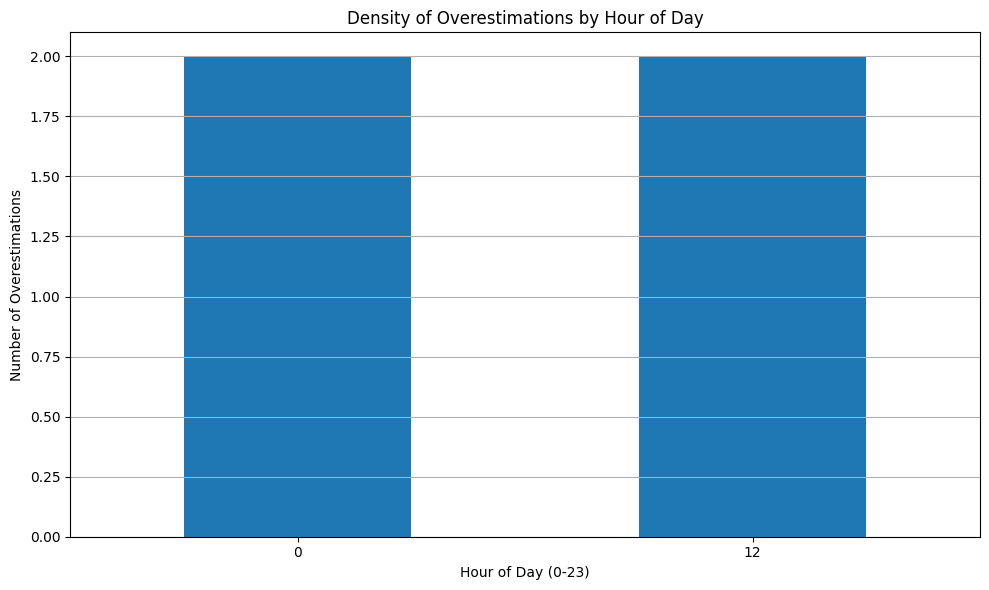

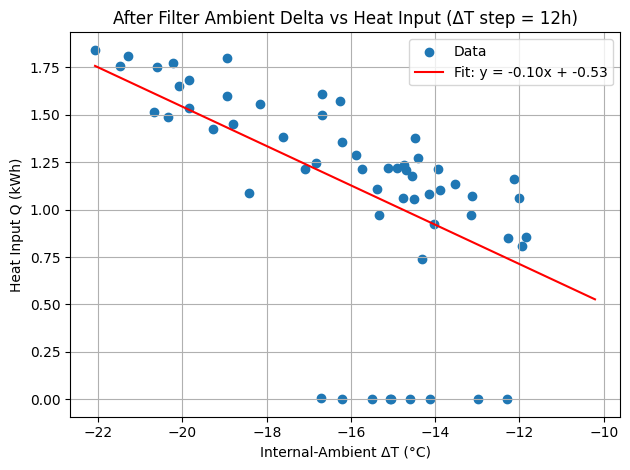

RMSE:[0.38428396]


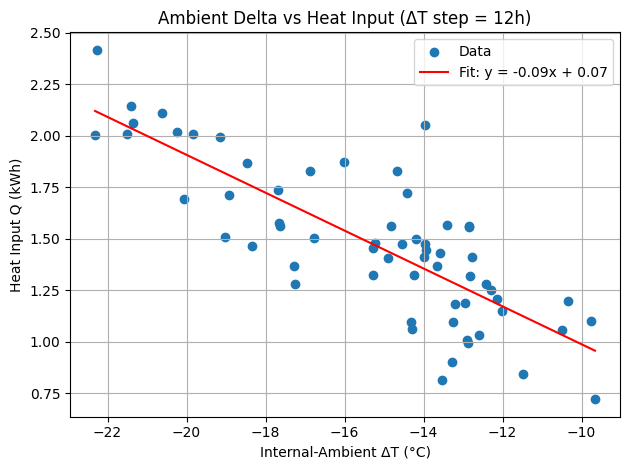

/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


All time windows above the regression line:
[(Timestamp('2023-01-04 00:00:00'), Timestamp('2023-01-04 00:00:00')), (Timestamp('2023-01-08 12:00:00'), Timestamp('2023-01-08 12:00:00')), (Timestamp('2023-01-13 00:00:00'), Timestamp('2023-01-13 00:00:00')), (Timestamp('2023-01-18 00:00:00'), Timestamp('2023-01-18 00:00:00')), (Timestamp('2023-01-21 00:00:00'), Timestamp('2023-01-21 00:00:00')), (Timestamp('2023-01-22 00:00:00'), Timestamp('2023-01-22 00:00:00')), (Timestamp('2023-01-28 00:00:00'), Timestamp('2023-01-28 00:00:00')), (Timestamp('2023-01-29 00:00:00'), Timestamp('2023-01-29 00:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


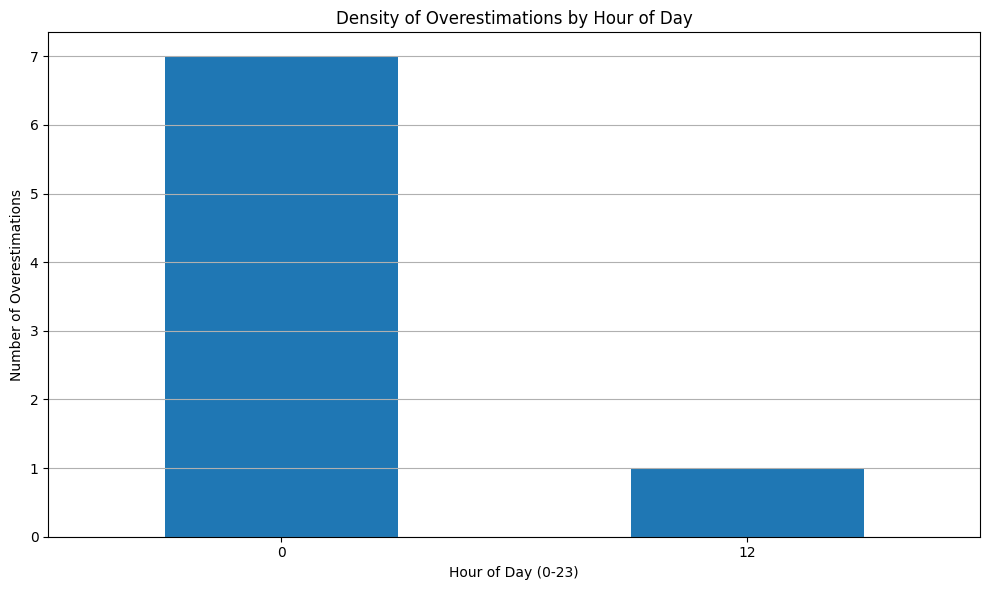

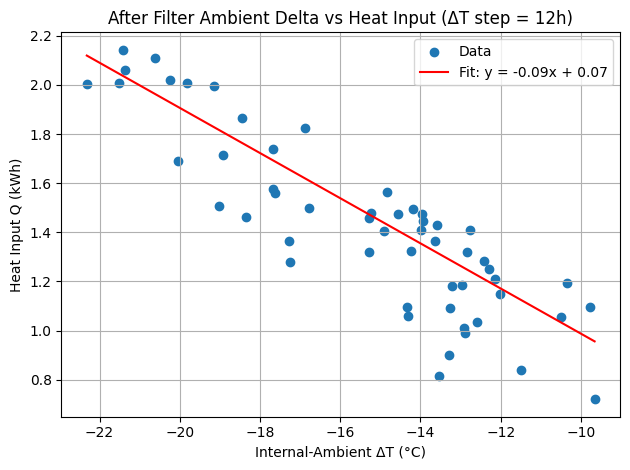

RMSE:[0.28299819]


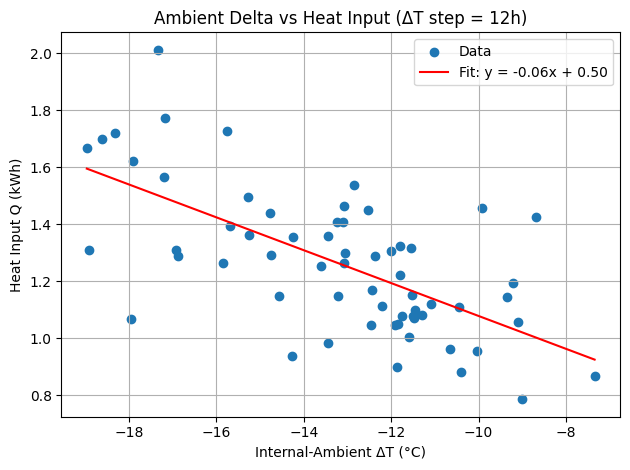

All time windows above the regression line:
[(Timestamp('2023-01-03 12:00:00'), Timestamp('2023-01-03 12:00:00')), (Timestamp('2023-01-10 12:00:00'), Timestamp('2023-01-10 12:00:00')), (Timestamp('2023-01-11 12:00:00'), Timestamp('2023-01-11 12:00:00')), (Timestamp('2023-01-12 12:00:00'), Timestamp('2023-01-12 12:00:00')), (Timestamp('2023-01-15 00:00:00'), Timestamp('2023-01-15 00:00:00')), (Timestamp('2023-01-17 12:00:00'), Timestamp('2023-01-17 12:00:00')), (Timestamp('2023-01-18 12:00:00'), Timestamp('2023-01-18 12:00:00')), (Timestamp('2023-01-19 12:00:00'), Timestamp('2023-01-19 12:00:00'))]
The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png


/var/folders/fk/0m0g9qgs7y5fc0br86wht_1m0000gn/T/ipykernel_8188/1327065239.py:133: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  above_windows = df_check[df_check["above_line"]].groupby("group").apply(


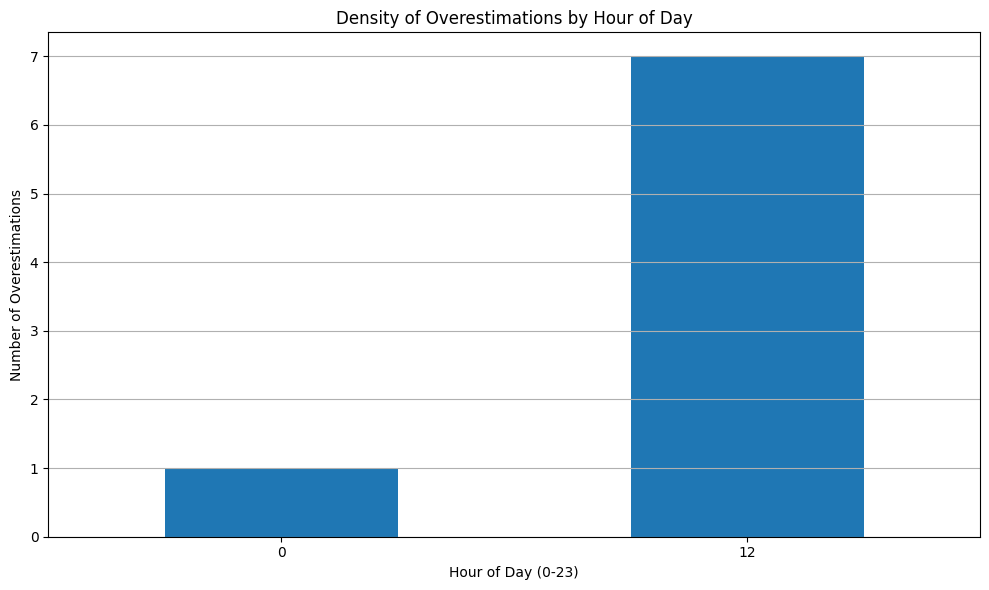

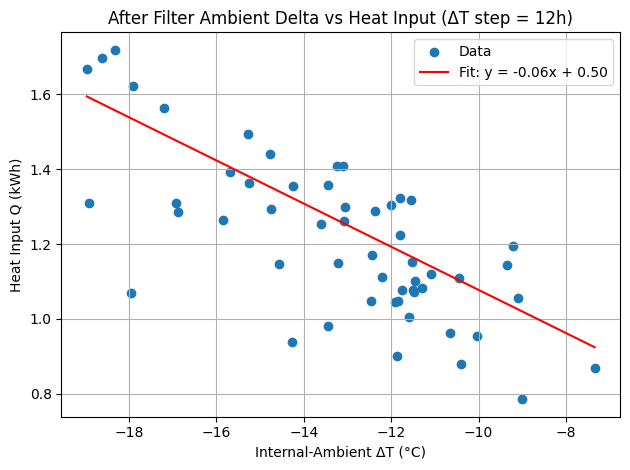

In [89]:



for id_use in unique_ids:
    
    floor_area = float(results[id_use][0][6:])
    no_storeys = float(results[id_use][1][6:])
    insulation = results[id_use][2][6:]
    hp_type = results[id_use][3][6:]
    rating = results[id_use][4][6:]
    C = results[id_use][5]
    R_a = results[id_use][6]
    w_s = results[id_use][7]
    w = results[id_use][9]
    
    home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")
    df_single = df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()
    
    #re-adjust Heat Pump Diff and add temp differences
    df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
        "Heat_Pump_Energy_Output"].diff()
    df_single["Internal_Temperature_Diff"] = df_single[
        "Internal_Air_Temperature"].diff()
    df_single["Internal_Ambient_Temperature_Diff"] = \
        (df_single["External_Air_Temperature"] -
         df_single["Internal_Air_Temperature"])
    
    # 1. Drop columns with almost all missing data (e.g., more than 90% missing)
    threshold = 0.90 * len(df_single)
    df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
    #print("Columns dropped due to high missing values:")
    #print(df_single.columns.difference(df_single_cleaned.columns).tolist())
    
    df_single = df_single_cleaned
    
    #print("\nColumns remaining after dropping highly missing columns:")
    #print(df_single.columns.tolist())
    
    df_single = df_single.set_index('Timestamp')
    df_single = df_single.sort_index()
    
    # Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
    numeric_cols = df_single.select_dtypes(include=['number']).columns
    df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
        method='time', limit=4, limit_direction='both')
    
    df_single_interpolated = df_single.copy()
    df_single_interpolated[numeric_cols] = df_single_numeric_interpolated
    
    # After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
    initial_rows = len(df_single_interpolated)
    df_single_processed = df_single_interpolated.dropna()
    df_heating_single = df_single_processed.copy()
    
    # Time range
    t_start = pd.to_datetime("2023-01-01 00:00:00")
    t_end = pd.to_datetime("2023-01-31 23:59:00")
    df_heating_only = df_heating_single[
        (df_heating_single.index >= t_start) & (df_heating_single.index <= t_end)
        ].copy()
    
    df_heating_only.drop("Property_ID", axis=1, inplace=True)
    df_heating_only.drop("half-hour", axis=1, inplace=True)
    df_heating_only.drop("Date", axis=1, inplace=True)
    df_heating_only.drop("has_data", axis=1, inplace=True)
    
    t_step_regres = 12

    # Select numeric columns and resample
    df_numeric = df_heating_only.select_dtypes(include='number')
    df_resampled = df_numeric.resample(f'{t_step_regres}h').mean()
    
    # Extract variables
    delta_T_a_heat = df_resampled["Internal_Ambient_Temperature_Diff"].dropna()
    q_heat_only = df_resampled["Heat_Pump_Energy_Output_Diff"].dropna()
    
    # Align lengths
    valid_idx = delta_T_a_heat.index.intersection(q_heat_only.index)
    delta_T_a_heat = delta_T_a_heat.loc[valid_idx]
    q_heat_only = q_heat_only.loc[valid_idx]
    
    # Regression (Y = a*X + b)
    Y = q_heat_only.values
    X = np.vstack([delta_T_a_heat.values, np.ones(len(delta_T_a_heat))]).T
    coef, resid, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    
    rmse = resid / np.sqrt(len(delta_T_a_heat.values))
    
    # Generate fit line
    x_step = np.linspace(delta_T_a_heat.min(), delta_T_a_heat.max(), 100)
    y_step = coef[0] * x_step + coef[1]
    
    print(f"RMSE:{rmse}")
    
    # Plot
    plt.figure()
    plt.scatter(delta_T_a_heat, q_heat_only, label="Data")
    plt.plot(x_step, y_step, 'r', label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}")
    plt.title(f"Ambient Delta vs Heat Input (ΔT step = {t_step_regres}h)")
    plt.xlabel("Internal-Ambient ΔT (°C)")
    plt.ylabel("Heat Input Q (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # Generate fit line
    x_step = np.linspace(delta_T_a_heat.min(), delta_T_a_heat.max(), 100)
    y_step = coef[0] * x_step + coef[1]
    
    # Compute predicted values
    predicted = coef[0] * delta_T_a_heat.values + coef[1]
    
    # Compute residuals
    residuals = q_heat_only.values - predicted
    
    # Compute RMSE
    rmse = np.sqrt(np.mean(residuals ** 2))
    
    # Mask: points that are more than 1 RMSE ABOVE the fit
    above_mask = residuals > rmse
    below_mask = residuals <= rmse
    # Convert to DataFrame for easier handling
    df_check = pd.DataFrame({
        "q_actual": q_heat_only.values,
        "q_predicted": predicted,
        "above_line": above_mask
    }, index=delta_T_a_heat.index)
    
    # Extract timestamps where actual > predicted
    above_points = df_check[df_check["above_line"]].index
    
    # Optionally, group into contiguous windows
    df_check["group"] = (
                df_check["above_line"] != df_check["above_line"].shift()).cumsum()
    above_windows = df_check[df_check["above_line"]].groupby("group").apply(
        lambda x: (x.index[0], x.index[-1])
    )
    
    print("All time windows above the regression line:")
    print(above_windows.tolist())
    
    hours = above_points.hour
    
    # Count the frequency of each hour
    hour_counts = hours.value_counts().sort_index()
    
    # Create a bar plot
    plt.figure(figsize=(10, 6))
    hour_counts.plot(kind='bar')
    plt.title('Density of Overestimations by Hour of Day')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Number of Overestimations')
    plt.xticks(rotation=0)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig('overestimations_by_hour.png')
    print('The bar plot of overestimations by hour of day has been saved as overestimations_by_hour.png')
    
    # Plot
    plt.figure()
    plt.scatter(delta_T_a_heat[below_mask], q_heat_only[below_mask],
                label="Data")
    plt.plot(x_step, y_step, 'r', label=f"Fit: y = {coef[0]:.2f}x + {coef[1]:.2f}")
    plt.title(f"After Filter Ambient Delta vs Heat Input (ΔT step = "
              f"{t_step_regres}h)")
    plt.xlabel("Internal-Ambient ΔT (°C)")
    plt.ylabel("Heat Input Q (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()